**All the required import libraries. 
Set up the virtual environment and download all the dependencies from requirements.txt**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

**Data Loading**

In [5]:
# Load training data
train = pd.read_csv("../dataset/train.csv")
test = pd.read_csv("../dataset/test.csv")

In [6]:
print(f"\nTraining Set Shape: {train.shape}")
print(f"Test Set Shape: {test.shape}")


Training Set Shape: (75000, 4)
Test Set Shape: (75000, 3)


In [7]:
# Display first few rows
print(train.head())

   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97  
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34  
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49  


**Data Inspection**

In [8]:
print("\n--- Column Information ---")
print(train.info())

print("\n--- Statistical Summary ---")
print(train.describe())

print("\n--- Missing Values ---")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\n--- Data Types ---")
print(train.dtypes)



--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB
None

--- Statistical Summary ---
           sample_id         price
count   75000.000000  75000.000000
mean   149841.917707     23.647654
std     86585.346513     33.376932
min         0.000000      0.130000
25%     73845.750000      6.795000
50%    150129.000000     14.000000
75%    225040.250000     28.625000
max    299438.000000   2796.000000

--- Missing Values ---
No missing values found!

--- Data Types ---
sample_id            int64
catalog_content     object
image_link          object
price              float64


**Price Distribution Analysis**

In [9]:
# Basic price statistics
print("\n--- Price Statistics ---")
print(f"Mean Price: ${train['price'].mean():.2f}")
print(f"Median Price: ${train['price'].median():.2f}")
print(f"Std Dev: ${train['price'].std():.2f}")
print(f"Min Price: ${train['price'].min():.2f}")
print(f"Max Price: ${train['price'].max():.2f}")
print(f"25th Percentile: ${train['price'].quantile(0.25):.2f}")
print(f"75th Percentile: ${train['price'].quantile(0.75):.2f}")
print(f"95th Percentile: ${train['price'].quantile(0.95):.2f}")
print(f"99th Percentile: ${train['price'].quantile(0.99):.2f}")


--- Price Statistics ---
Mean Price: $23.65
Median Price: $14.00
Std Dev: $33.38
Min Price: $0.13
Max Price: $2796.00
25th Percentile: $6.79
75th Percentile: $28.62
95th Percentile: $75.71
99th Percentile: $145.25


In [10]:
# Check for skewness
skewness = train["price"].skew()
print(f"\nPrice Skewness: {skewness:.2f}")
if skewness > 1:
    print(" Highly right-skewed distribution - consider log transformation")
elif skewness > 0.5:
    print(" Moderately right-skewed distribution")


Price Skewness: 13.60
 Highly right-skewed distribution - consider log transformation


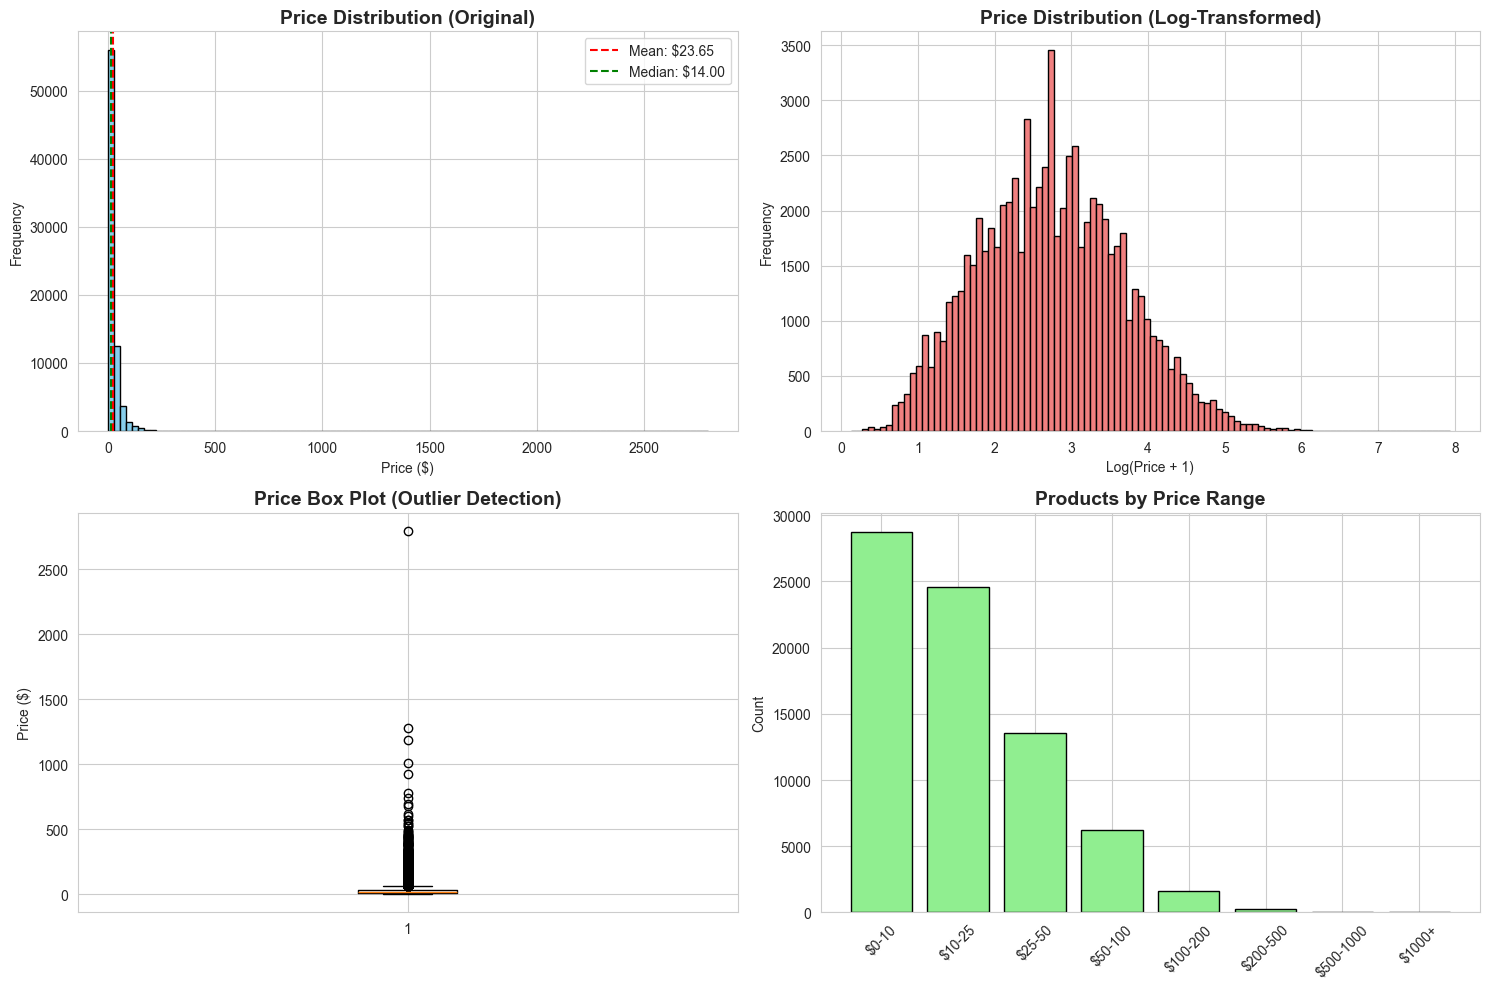

In [25]:
# Visualize price distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original distribution
axes[0, 0].hist(train["price"], bins=100, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Price Distribution (Original)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Price ($)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(
    train["price"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: ${train['price'].mean():.2f}",
)
axes[0, 0].axvline(
    train["price"].median(),
    color="green",
    linestyle="--",
    label=f"Median: ${train['price'].median():.2f}",
)
axes[0, 0].legend()

# Log-transformed distribution
axes[0, 1].hist(
    np.log1p(train["price"]), bins=100, color="lightcoral", edgecolor="black"
)
axes[0, 1].set_title(
    "Price Distribution (Log-Transformed)", fontsize=14, fontweight="bold"
)
axes[0, 1].set_xlabel("Log(Price + 1)")
axes[0, 1].set_ylabel("Frequency")

# Box plot
axes[1, 0].boxplot(train["price"], vert=True)
axes[1, 0].set_title(
    "Price Box Plot (Outlier Detection)", fontsize=14, fontweight="bold"
)
axes[1, 0].set_ylabel("Price ($)")

# Price ranges
price_ranges = pd.cut(
    train["price"],
    bins=[0, 10, 25, 50, 100, 200, 500, 1000, float("inf")],
    labels=[
        "$0-10",
        "$10-25",
        "$25-50",
        "$50-100",
        "$100-200",
        "$200-500",
        "$500-1000",
        "$1000+",
    ],
)
price_range_counts = price_ranges.value_counts().sort_index()
axes[1, 1].bar(
    range(len(price_range_counts)),
    price_range_counts.values,
    color="lightgreen",
    edgecolor="black",
)
axes[1, 1].set_xticks(range(len(price_range_counts)))
axes[1, 1].set_xticklabels(price_range_counts.index, rotation=45)
axes[1, 1].set_title("Products by Price Range", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Catalog Content Analysis or Text Analysis**

In [14]:
# Text length analysis
train["text_length"] = train["catalog_content"].str.len()
train["word_count"] = train["catalog_content"].str.split().str.len()

print("\n--- Text Statistics ---")
print(f"Average Text Length: {train['text_length'].mean():.2f} characters")
print(f"Median Text Length: {train['text_length'].median():.2f} characters")
print(f"Average Word Count: {train['word_count'].mean():.2f} words")
print(f"Min Text Length: {train['text_length'].min()} characters")
print(f"Max Text Length: {train['text_length'].max()} characters")


--- Text Statistics ---
Average Text Length: 908.89 characters
Median Text Length: 643.00 characters
Average Word Count: 147.85 words
Min Text Length: 32 characters
Max Text Length: 7894 characters


In [15]:
# Correlation between text features and price
print("\n--- Correlation with Price ---")
print(f"Text Length vs Price: {train['text_length'].corr(train['price']):.3f}")
print(f"Word Count vs Price: {train['word_count'].corr(train['price']):.3f}")


--- Correlation with Price ---
Text Length vs Price: 0.147
Word Count vs Price: 0.144


In [16]:
# Extract Item Pack Quantity (IPQ)
def extract_ipq(text):
    """Extract Item Pack Quantity from catalog content"""
    if pd.isna(text):
        return 1

    text = str(text).lower()

    # Pattern 1: "pack of X", "X pack", "X-pack"
    patterns = [
        r"pack of (\d+)",
        r"(\d+) pack",
        r"(\d+)-pack",
        r"(\d+)pack",
        r"set of (\d+)",
        r"(\d+) count",
        r"(\d+)-count",
        r"count[:\s]+(\d+)",
        r"quantity[:\s]+(\d+)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))

    return 1  # Default to 1 if no pack quantity found


train["ipq"] = train["catalog_content"].apply(extract_ipq)

print("\n--- Item Pack Quantity (IPQ) Analysis ---")
print(
    f"Products with IPQ > 1: {(train['ipq'] > 1).sum()} ({(train['ipq'] > 1).sum() / len(train) * 100:.1f}%)"
)
print(f"Average IPQ: {train['ipq'].mean():.2f}")
print(f"Max IPQ: {train['ipq'].max()}")
print("\nIPQ Distribution:")
print(train["ipq"].value_counts().head(10))

# IPQ vs Price correlation
print(f"\n IPQ vs Price Correlation: {train['ipq'].corr(train['price']):.3f}")


--- Item Pack Quantity (IPQ) Analysis ---
Products with IPQ > 1: 29840 (39.8%)
Average IPQ: 11380300.43
Max IPQ: 853522000542

IPQ Distribution:
ipq
1     45145
6      5470
12     5164
2      4554
3      3936
4      2393
24     1428
8      1215
10      788
5       540
Name: count, dtype: int64

 IPQ vs Price Correlation: 0.010


In [17]:
# Extract brand indicators
def has_brand_keywords(text):
    """Check if text contains brand-like patterns"""
    if pd.isna(text):
        return 0

    text = str(text).lower()

    # Common brand indicators
    brand_keywords = [
        "brand",
        "by ",
        "amazon",
        "basics",
        "premium",
        "pro",
        "professional",
        "deluxe",
        "ultra",
        "plus",
        "max",
        "elite",
    ]

    return int(any(keyword in text for keyword in brand_keywords))


train["has_brand"] = train["catalog_content"].apply(has_brand_keywords)

print("\n--- Brand Presence Analysis ---")
print(
    f"Products with brand indicators: {train['has_brand'].sum()} ({train['has_brand'].sum() / len(train) * 100:.1f}%)"
)
print(f"Avg price WITH brand: ${train[train['has_brand'] == 1]['price'].mean():.2f}")
print(f"Avg price WITHOUT brand: ${train[train['has_brand'] == 0]['price'].mean():.2f}")
print(
    f"Price difference: {((train[train['has_brand'] == 1]['price'].mean() / train[train['has_brand'] == 0]['price'].mean() - 1) * 100):.1f}%"
)



--- Brand Presence Analysis ---
Products with brand indicators: 51487 (68.6%)
Avg price WITH brand: $25.88
Avg price WITHOUT brand: $18.76
Price difference: 37.9%


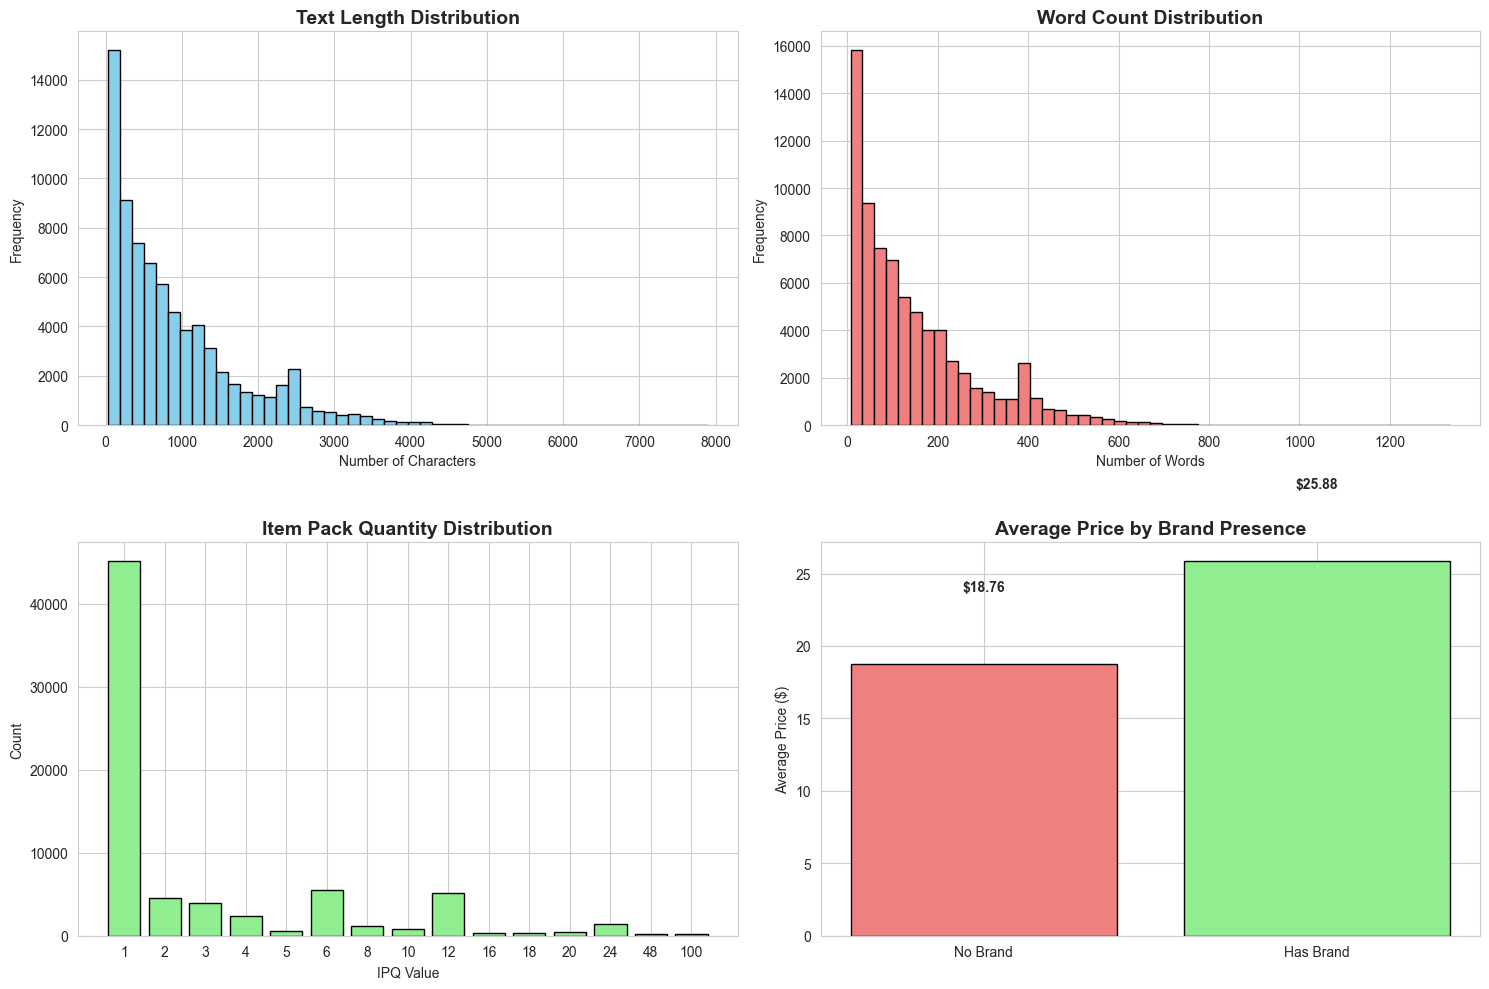

In [18]:
# Visualize text features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(train["text_length"], bins=50, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Text Length Distribution", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Number of Characters")
axes[0, 0].set_ylabel("Frequency")

# Word count distribution
axes[0, 1].hist(train["word_count"], bins=50, color="lightcoral", edgecolor="black")
axes[0, 1].set_title("Word Count Distribution", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Number of Words")
axes[0, 1].set_ylabel("Frequency")

# IPQ distribution
ipq_counts = train["ipq"].value_counts().head(15).sort_index()
axes[1, 0].bar(
    range(len(ipq_counts)), ipq_counts.values, color="lightgreen", edgecolor="black"
)
axes[1, 0].set_xticks(range(len(ipq_counts)))
axes[1, 0].set_xticklabels(ipq_counts.index)
axes[1, 0].set_title("Item Pack Quantity Distribution", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("IPQ Value")
axes[1, 0].set_ylabel("Count")

# Price by brand presence
brand_prices = train.groupby("has_brand")["price"].mean()
axes[1, 1].bar(
    ["No Brand", "Has Brand"],
    brand_prices.values,
    color=["lightcoral", "lightgreen"],
    edgecolor="black",
)
axes[1, 1].set_title("Average Price by Brand Presence", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Average Price ($)")
for i, v in enumerate(brand_prices.values):
    axes[1, 1].text(i, v + 5, f"${v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Keyword Analysis**

In [19]:
# Extract common words
all_words = []
for text in train["catalog_content"].dropna():
    words = str(text).lower().split()
    # Filter out very short words
    words = [w for w in words if len(w) > 3]
    all_words.extend(words)

word_freq = Counter(all_words)
print("\n--- Top 30 Most Common Keywords ---")
for word, count in word_freq.most_common(30):
    print(f"{word:20s}: {count:6d}")


--- Top 30 Most Common Keywords ---
bullet              : 267689
point               : 261624
with                : 141873
your                :  80520
item                :  77722
name:               :  75265
value:              :  75121
unit:               :  75014
ounce               :  57344
that                :  47662
product             :  42123
from                :  38821
this                :  37104
flavor              :  35878
coffee              :  33411
description:        :  32610
perfect             :  32410
natural             :  31323
made                :  31072
organic             :  29373
taste               :  25295
delicious           :  22885
free                :  22831
count               :  22794
into                :  22300
chocolate           :  22032
candy               :  21366
enjoy               :  20672
great               :  19744
these               :  19277


In [20]:
# Premium keywords analysis
premium_keywords = [
    "premium",
    "professional",
    "pro",
    "deluxe",
    "ultra",
    "elite",
    "luxury",
    "advanced",
    "superior",
    "quality",
]
budget_keywords = ["basic", "standard", "value", "economy", "simple", "generic"]

train["has_premium_keyword"] = (
    train["catalog_content"]
    .str.lower()
    .str.contains("|".join(premium_keywords), na=False)
    .astype(int)
)
train["has_budget_keyword"] = (
    train["catalog_content"]
    .str.lower()
    .str.contains("|".join(budget_keywords), na=False)
    .astype(int)
)

print("\n--- Premium vs Budget Keywords ---")
print(f"Products with premium keywords: {train['has_premium_keyword'].sum()}")
print(
    f"Avg price with premium keywords: ${train[train['has_premium_keyword'] == 1]['price'].mean():.2f}"
)
print(f"Products with budget keywords: {train['has_budget_keyword'].sum()}")
print(
    f"Avg price with budget keywords: ${train[train['has_budget_keyword'] == 0]['price'].mean():.2f}"
)


--- Premium vs Budget Keywords ---
Products with premium keywords: 49801
Avg price with premium keywords: $26.20
Products with budget keywords: 75000
Avg price with budget keywords: $nan


**Image Link Analysis**

In [21]:
print("\n--- Image Link Statistics ---")
print(f"Total image links: {train['image_link'].notna().sum()}")
print(f"Missing image links: {train['image_link'].isna().sum()}")

# Sample image links
print("\n--- Sample Image Links ---")
for i, link in enumerate(train["image_link"].head(5)):
    print(f"{i + 1}. {link}")

print("\n Note: Use src/utils.py download_images() function to download images")
print(
    "   Image features can be extracted using pre-trained models (ResNet, EfficientNet, etc.)"
)


--- Image Link Statistics ---
Total image links: 75000
Missing image links: 0

--- Sample Image Links ---
1. https://m.media-amazon.com/images/I/51mo8htwTHL.jpg
2. https://m.media-amazon.com/images/I/71YtriIHAAL.jpg
3. https://m.media-amazon.com/images/I/51+PFEe-w-L.jpg
4. https://m.media-amazon.com/images/I/41mu0HAToDL.jpg
5. https://m.media-amazon.com/images/I/41sA037+QvL.jpg

 Note: Use src/utils.py download_images() function to download images
   Image features can be extracted using pre-trained models (ResNet, EfficientNet, etc.)


IPQ v/s Price Detalied Analysis


--- Average Price by IPQ ---
      mean  median  count
ipq                      
0    21.73   17.99     15
1    22.37   12.99  45145
2    26.92   18.91   4554
3    30.73   18.74   3936
4    20.23   12.52   2393
5    18.08   10.49    540
6    23.77   15.00   5470
7    20.77   15.52    100
8    19.64    9.33   1215
9    23.77   16.68    151
10   23.52   12.99    788
11   30.92   31.00     22
12   24.98   15.88   5164
14   28.84   18.74     74
15   27.14   15.24    188
16   24.25   17.80    283
18   21.91   16.26    356
20   28.31   14.41    436
21   21.58   17.73     19
22   17.08   18.49     67


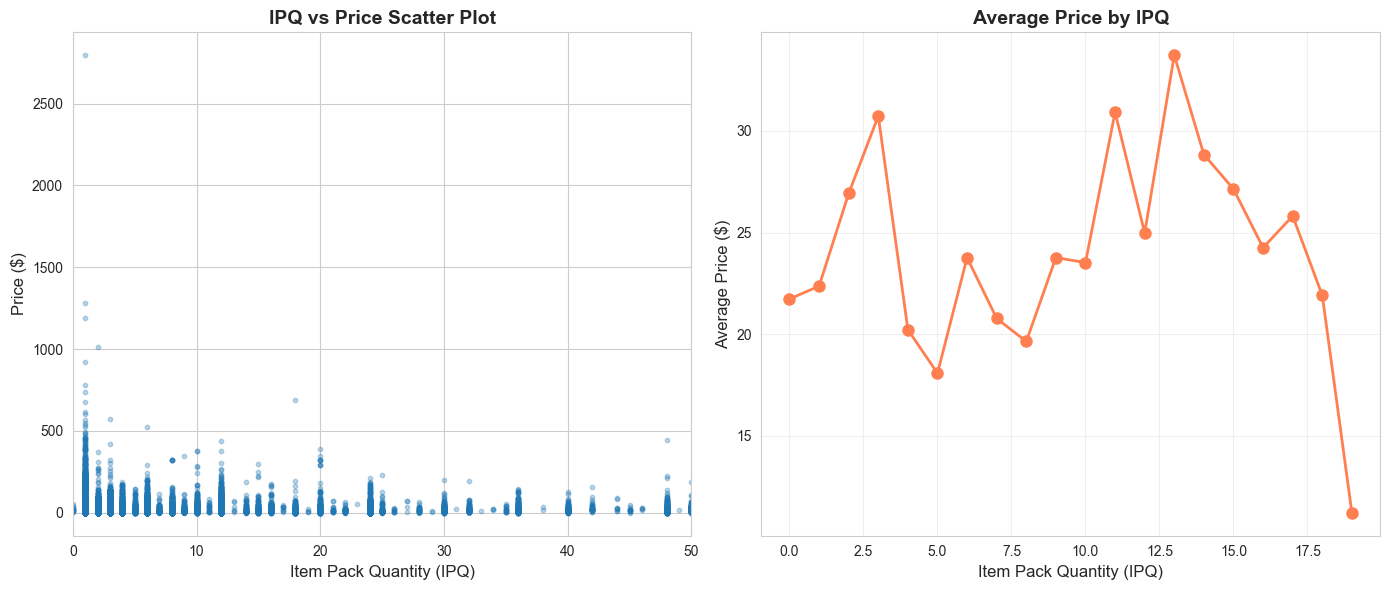

In [22]:
ipq_price = train.groupby("ipq")["price"].agg(["mean", "median", "count"]).round(2)
ipq_price = ipq_price[ipq_price["count"] >= 10].head(
    20
)  # Filter for sufficient samples

print("\n--- Average Price by IPQ ---")
print(ipq_price)

# Plot IPQ vs Price
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(train["ipq"], train["price"], alpha=0.3, s=10)
plt.xlabel("Item Pack Quantity (IPQ)", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.title("IPQ vs Price Scatter Plot", fontsize=14, fontweight="bold")
plt.xlim(0, 50)  # Limit x-axis for better visualization

plt.subplot(1, 2, 2)
ipq_avg = train.groupby("ipq")["price"].mean().head(20)
plt.plot(
    ipq_avg.index, ipq_avg.values, marker="o", linewidth=2, markersize=8, color="coral"
)
plt.xlabel("Item Pack Quantity (IPQ)", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.title("Average Price by IPQ", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Correlation Analysis**


--- Correlation with Price ---
price                  1.000000
text_length            0.146752
word_count             0.144423
has_premium_keyword    0.107678
has_brand              0.098933
ipq                    0.010005
has_budget_keyword          NaN
Name: price, dtype: float64


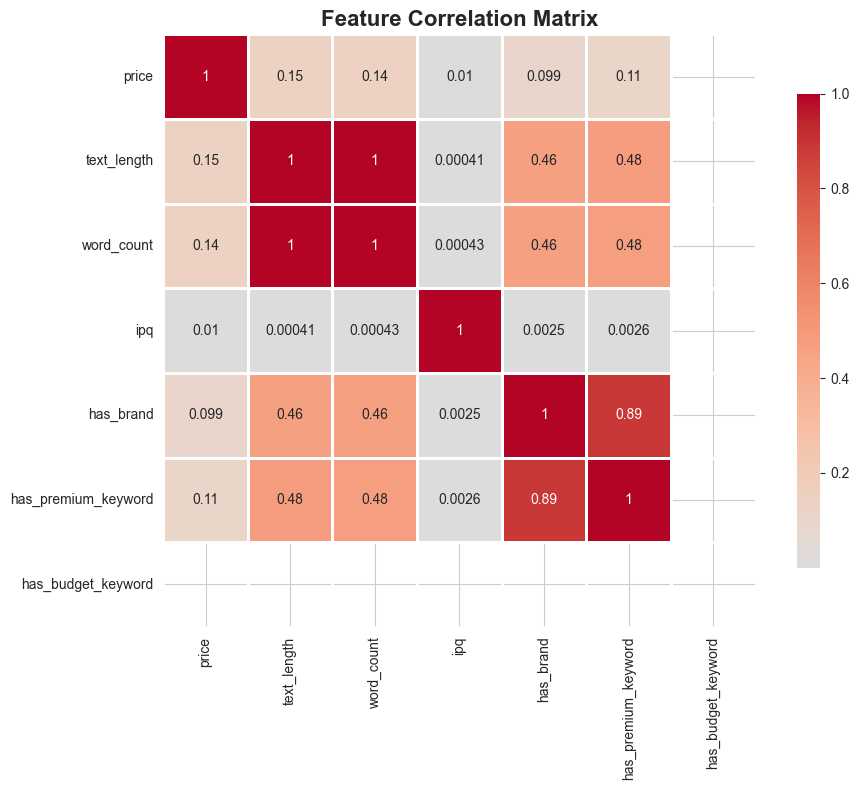

In [23]:
# Create correlation matrix for numerical features
numerical_features = [
    "price",
    "text_length",
    "word_count",
    "ipq",
    "has_brand",
    "has_premium_keyword",
    "has_budget_keyword",
]

correlation_matrix = train[numerical_features].corr()

print("\n--- Correlation with Price ---")
price_corr = correlation_matrix["price"].sort_values(ascending=False)
print(price_corr)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Outlier Detection**

In [24]:
# IQR method for outlier detection
Q1 = train["price"].quantile(0.25)
Q3 = train["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[(train["price"] < lower_bound) | (train["price"] > upper_bound)]

print("\n--- Outlier Statistics ---")
print(f"Lower Bound: ${lower_bound:.2f}")
print(f"Upper Bound: ${upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)} ({len(outliers) / len(train) * 100:.2f}%)")
print("\nHighest priced products:")
print(train.nlargest(10, "price")[["sample_id", "catalog_content", "price"]])


--- Outlier Statistics ---
Lower Bound: $-25.95
Upper Bound: $61.37
Number of outliers: 5524 (7.37%)

Highest priced products:
       sample_id                                    catalog_content    price
58617     229126  Item Name: 4Patriots 1-Year Survival Food Kit:...  2796.00
32153     134909  Item Name: Royal Amber Osetra Caviar - Russian...  1280.00
22839      62251  Item Name: 495 days proteins meal 33 bottles x...  1188.00
46301     195806  Item Name: China Beauty Rings Tea (Loose) (8 o...  1010.54
68388     236048  Item Name: Organic Pistachios Shelled Raw, 30 ...   921.50
72853     262694  Item Name: Numanna Family Pack Bucket 432 Serv...   779.25
73067     190026  Item Name: Crystal Geyser Pallet Of 84 Cases, ...   739.99
45580     272914  Item Name: Topps Juicy Drop Pop, 18 count per ...   691.16
56075     227791  Item Name: Alex's Low Acid Organic Coffee Ulti...   679.92
4146       46413  Item Name: Beverage/Topping Heated Condiment D...   613.58
